# Credit Card Fraud — Exploratory Data Analysis

Understanding the Kaggle `mlg-ulb/creditcardfraud` dataset before modeling: class distribution, feature behavior, temporal patterns, and which features discriminate fraud from legitimate transactions.

Features `V1`–`V28` are already PCA-transformed (the raw features are anonymized for privacy). Only `Time` and `Amount` are in their original units.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_dataframe

sns.set_theme(style="whitegrid")
df = load_dataframe()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

In [2]:
print(f"shape: {df.shape}")
print(f"missing values (total): {df.isnull().sum().sum()}")
print(f"dtypes:\n{df.dtypes.value_counts().to_string()}")
df.describe().T

shape: (284807, 31)
missing values (total): 0
dtypes:
float64    30
int64       1


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Class Imbalance

Fraud is ~0.17% of transactions — extreme imbalance. This is why the pipeline uses precision-recall curves instead of ROC, and why naive accuracy is meaningless here (a model predicting "not fraud" 100% of the time would score 99.83% accuracy).

In [3]:
counts = df["Class"].value_counts()
pct = df["Class"].value_counts(normalize=True) * 100
pd.DataFrame({"count": counts, "percentage": pct.round(4)})

,count,percentage
Class,,
0,284315,99.8273
1,492,0.1727


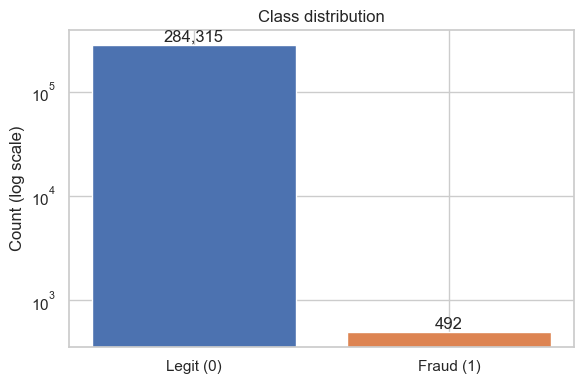

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4c72b0", "#dd8452"]
bars = ax.bar(["Legit (0)", "Fraud (1)"], counts.values, color=colors)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution")
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{n:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Transaction Amount Distribution

`Amount` is heavy-tailed (a few very large transactions, most small). That is why the pipeline uses `RobustScaler` on `Amount` — it's resistant to outliers in a way that `StandardScaler` isn't.

In [5]:
amt_stats = df.groupby("Class")["Amount"].agg(["count", "mean", "median", "std", "max"]).round(2)
amt_stats

,count,mean,median,std,max
Class,,,,,
0,284315,88.29,22.00,250.11,25691.16
1,492,122.21,9.25,256.68,2125.87


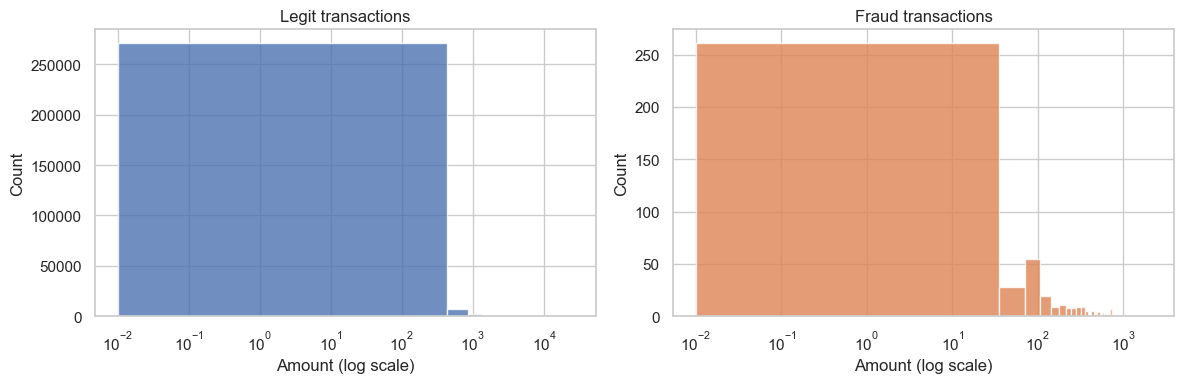

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls, color, label in zip(axes, [0, 1], ["#4c72b0", "#dd8452"], ["Legit", "Fraud"]):
    subset = df.loc[df["Class"] == cls, "Amount"]
    ax.hist(subset[subset > 0], bins=60, color=color, alpha=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Amount (log scale)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} transactions")
plt.tight_layout()
plt.show()

## Temporal Patterns

`Time` is seconds elapsed since the first transaction, and the dataset covers roughly 48 hours. Deriving hour-of-day lets us check whether fraud rate is uniform throughout the day or clusters at specific times.

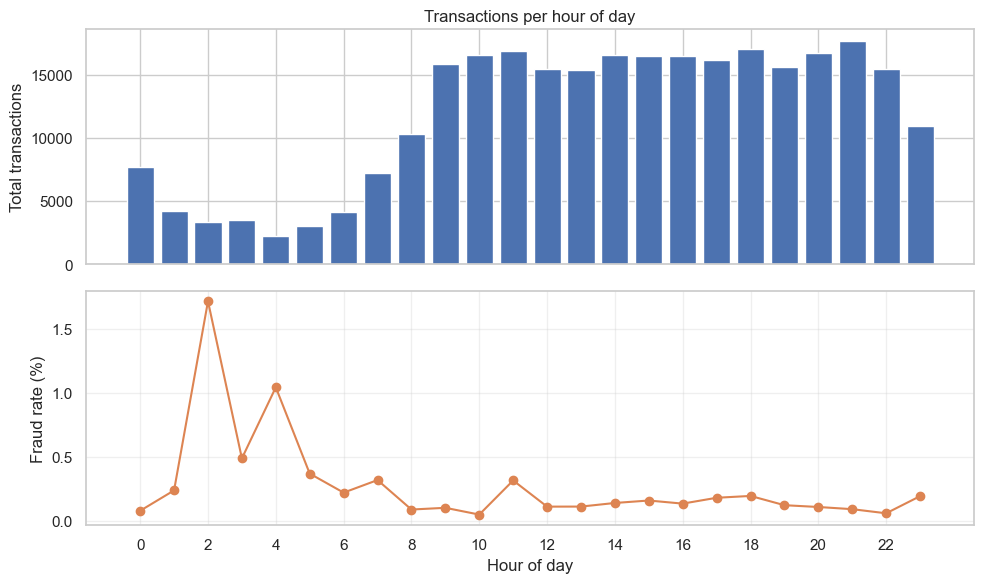

In [7]:
df["hour"] = (df["Time"] // 3600) % 24
hourly = df.groupby("hour").agg(total=("Class", "size"), frauds=("Class", "sum"))
hourly["fraud_rate"] = hourly["frauds"] / hourly["total"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.bar(hourly.index, hourly["total"], color="#4c72b0")
ax1.set_ylabel("Total transactions")
ax1.set_title("Transactions per hour of day")

ax2.plot(hourly.index, hourly["fraud_rate"] * 100, color="#dd8452", marker="o")
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Fraud rate (%)")
ax2.set_xticks(range(0, 24, 2))
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Separation

Which PCA features best separate fraud from legitimate transactions? Rank by the absolute correlation of each `V` feature with the `Class` target, then visualize the top 6.

In [8]:
v_cols = [c for c in df.columns if c.startswith("V")]
corrs = df[v_cols + ["Class"]].corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_features = corrs.head(6).index.tolist()
print("Top 6 features by |corr(V, Class)|:")
print(corrs.head(6).round(4).to_string())

Top 6 features by |corr(V, Class)|:
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930


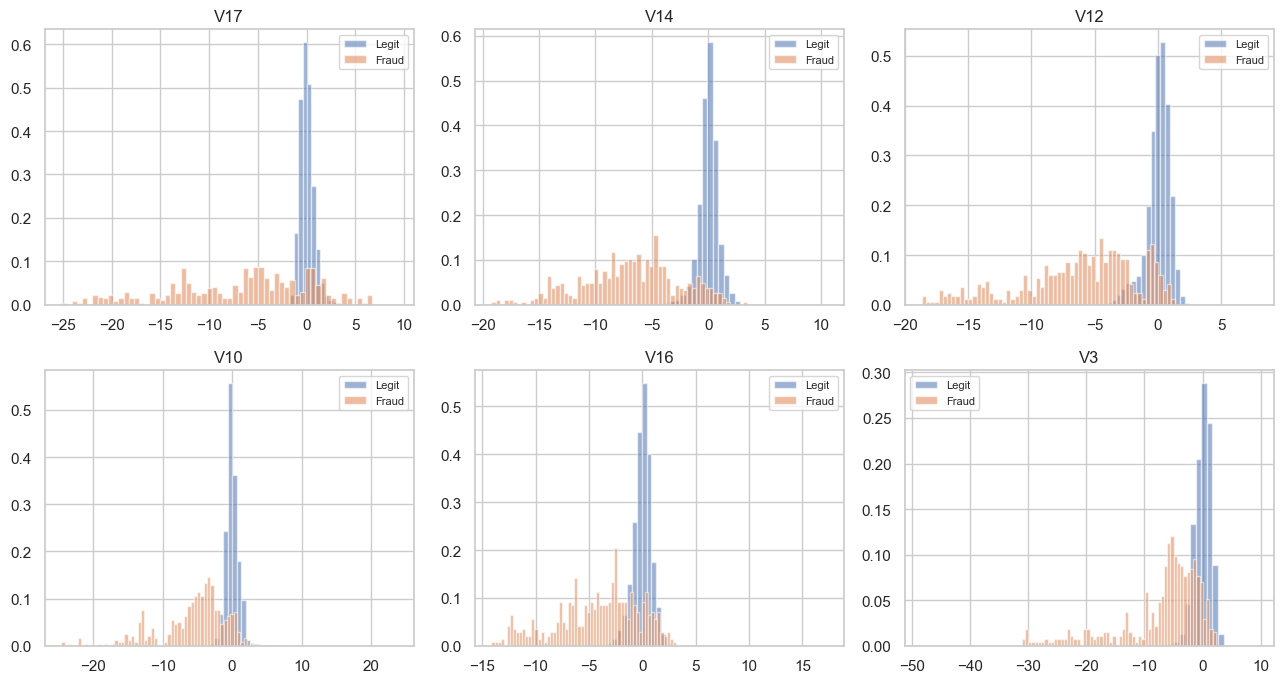

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, top_features):
    for cls, color, label in [(0, "#4c72b0", "Legit"), (1, "#dd8452", "Fraud")]:
        subset = df.loc[df["Class"] == cls, feat]
        ax.hist(subset, bins=60, density=True, alpha=0.55, color=color, label=label)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## All V-Features: Correlation with Target

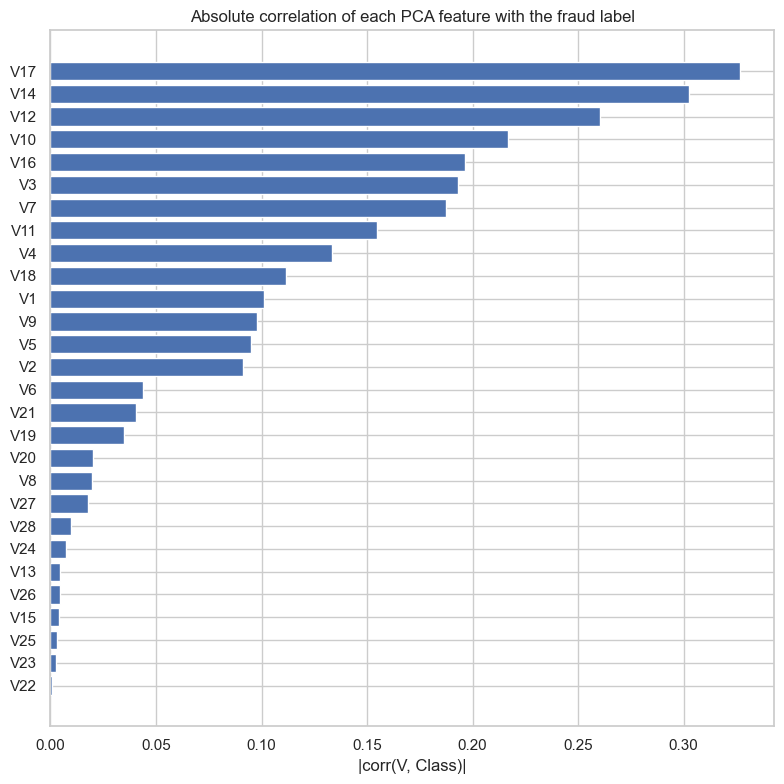

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
corrs_sorted = corrs.sort_values()
ax.barh(corrs_sorted.index, corrs_sorted.values, color="#4c72b0")
ax.set_xlabel("|corr(V, Class)|")
ax.set_title("Absolute correlation of each PCA feature with the fraud label")
plt.tight_layout()
plt.show()

## Takeaways

- Classes are extreme (~0.17% fraud). PR curves and average precision are the right metrics here — ROC would be misleading.
- `Amount` is heavy-tailed. `RobustScaler` on `Amount` and `Time` is the appropriate choice.
- Fraud rate varies meaningfully by hour of day — there's signal in the time dimension that the PCA-transformed features may or may not capture.
- A handful of V-features (typically `V14`, `V17`, `V12`, `V10`, `V16`, `V11`) carry most of the discriminative signal. Tree-based models should pick these up naturally; logistic regression benefits from them being the strongest linear signals.
- V-features are already standardized PCA components, so no further scaling is needed on them.

Next step: `scripts/run_pipeline.py` trains all three model families (LogReg, Random Forest, XGBoost) under all three imbalance-handling strategies (class weights, SMOTE, undersampling) and compares them.